--- STARTING IN-DEPTH VISUALIZATIONS FOR BERLIN ---
--- LOADING AGGREGATED DATA ---


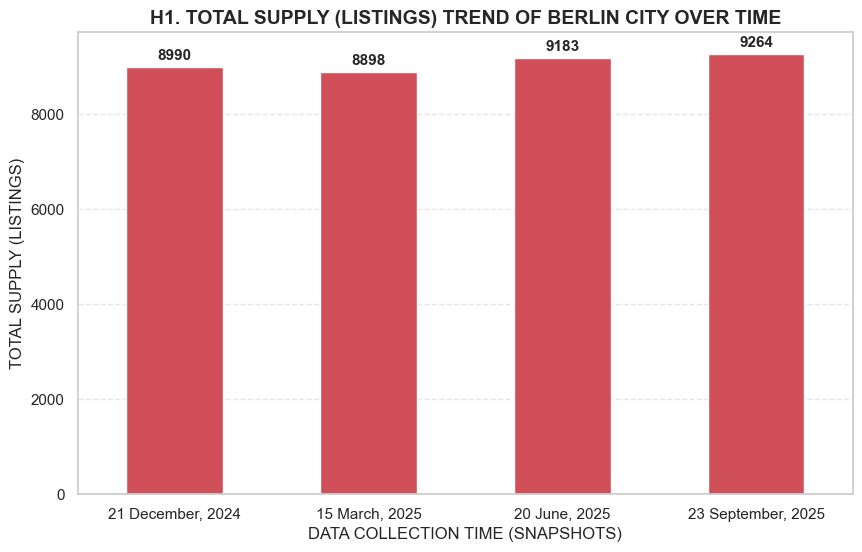

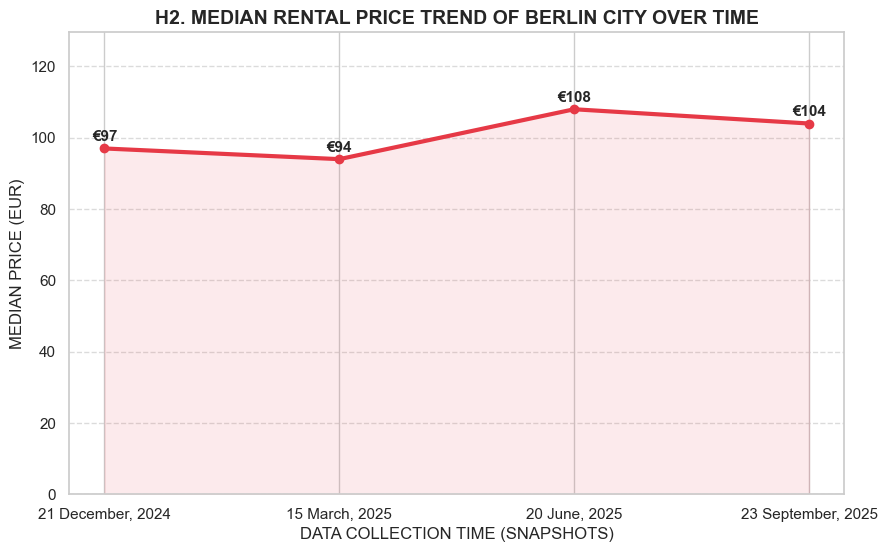

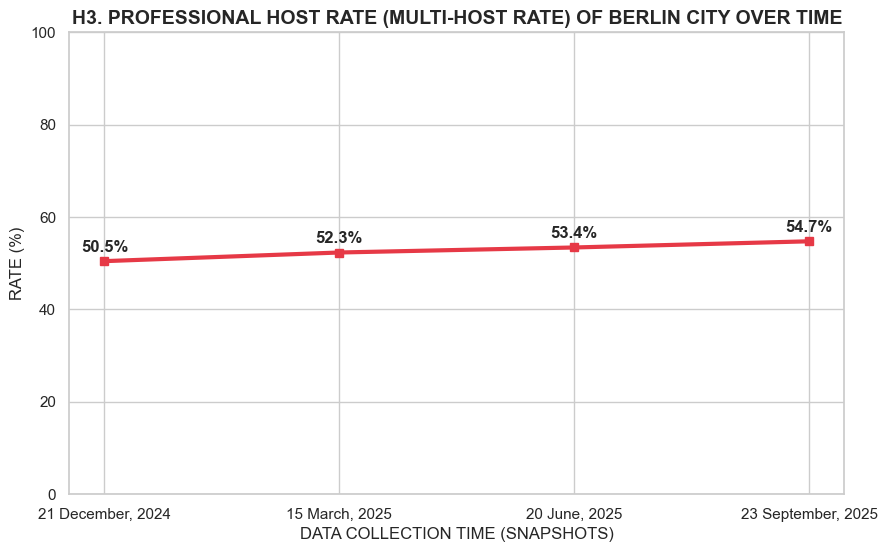

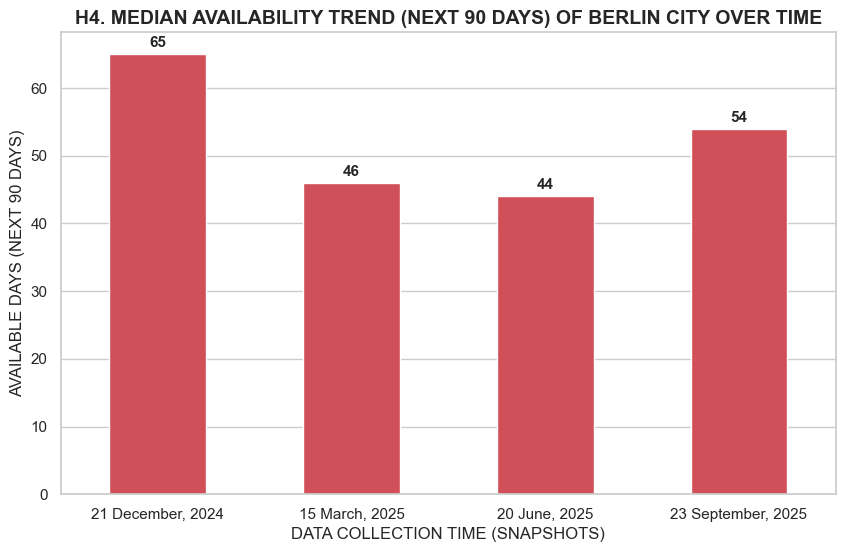

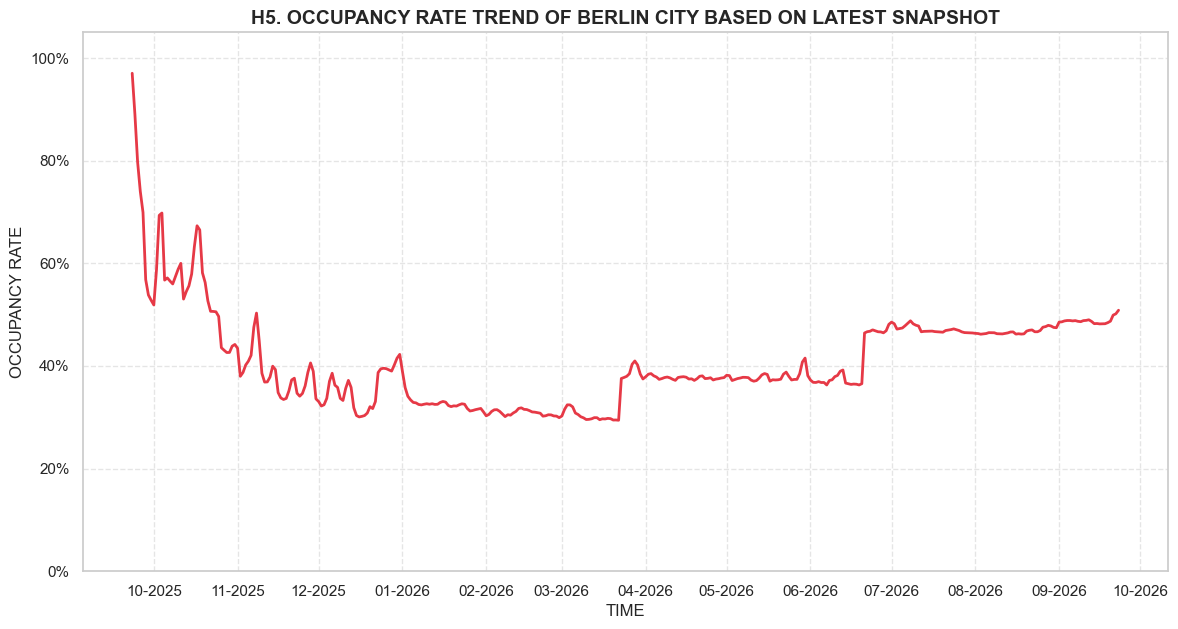

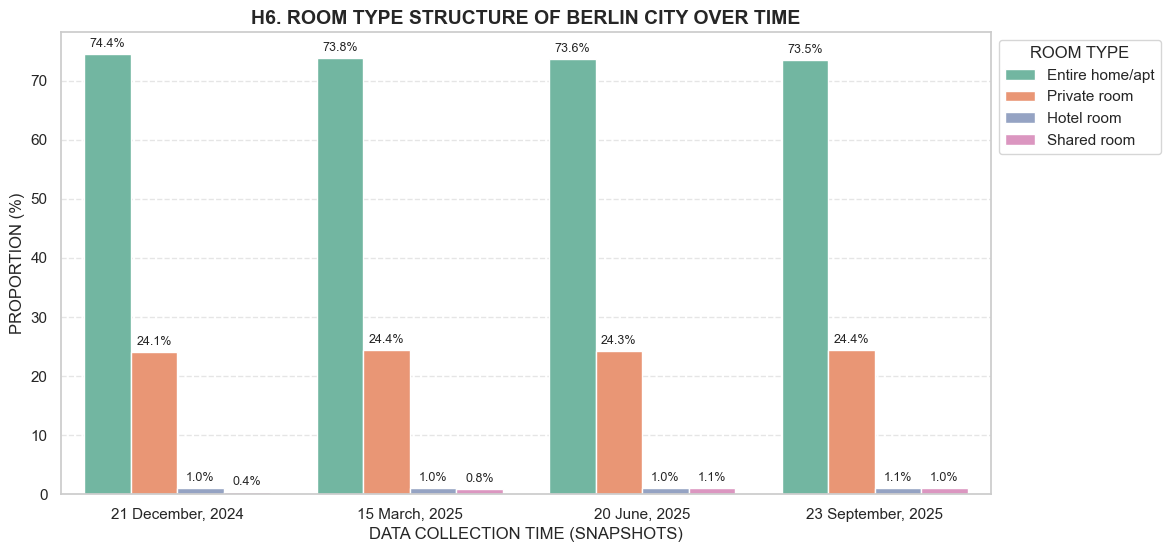

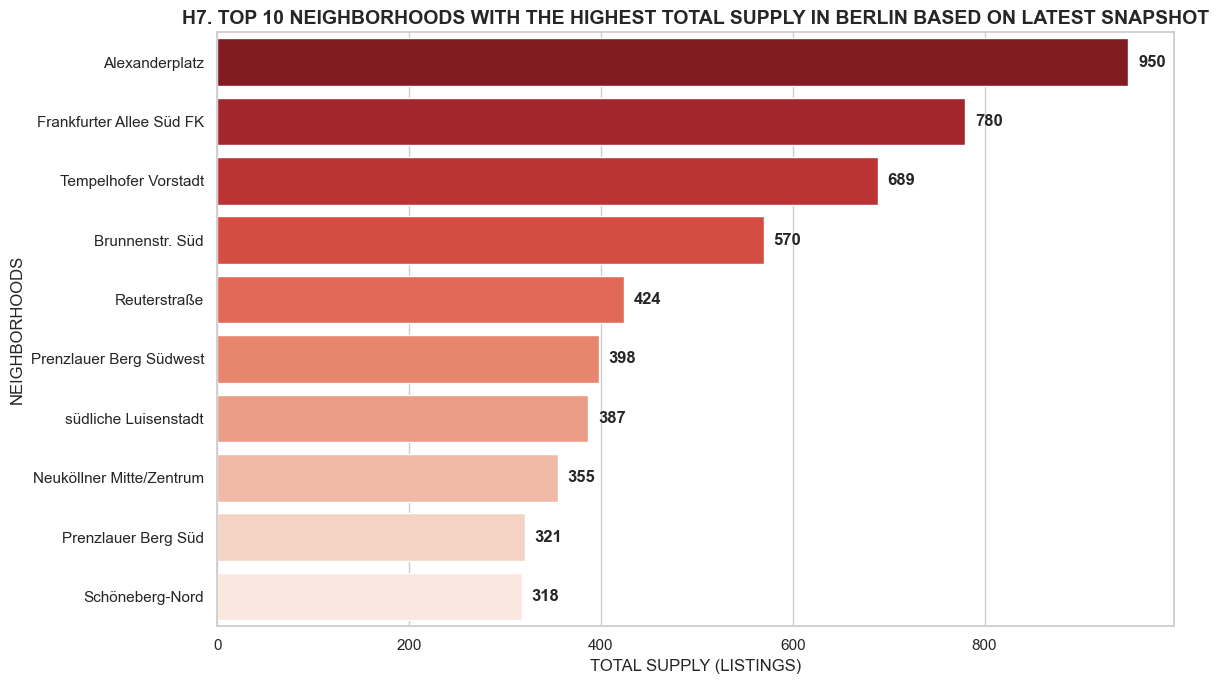

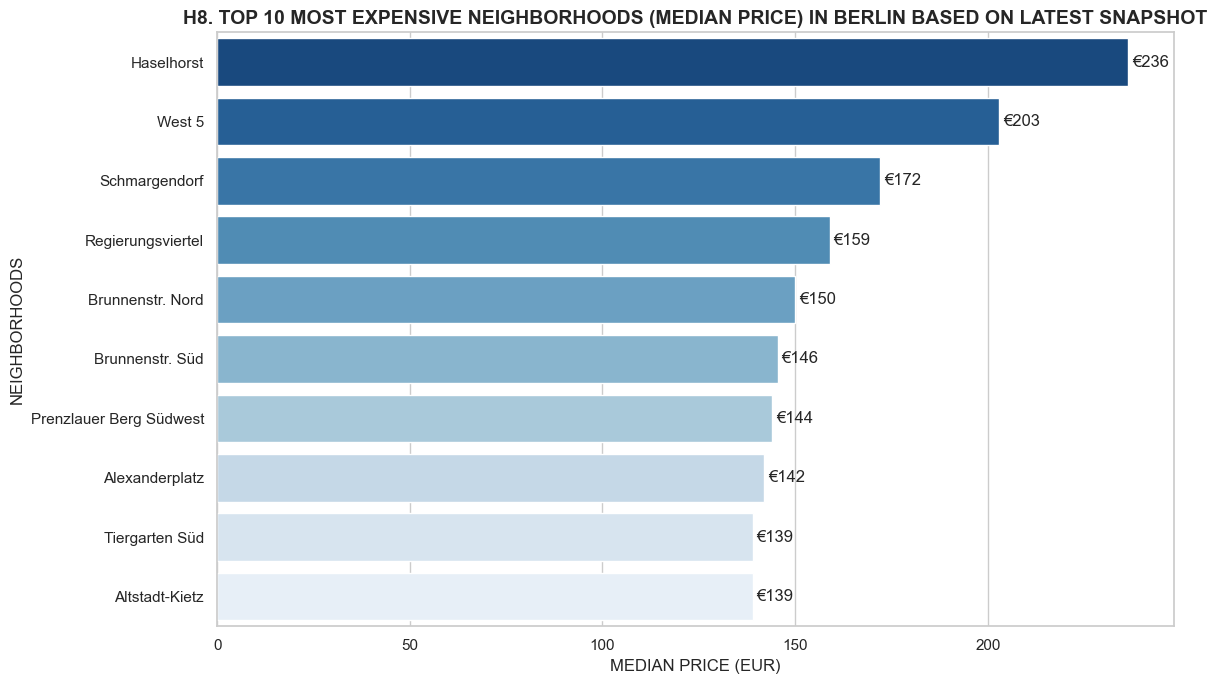

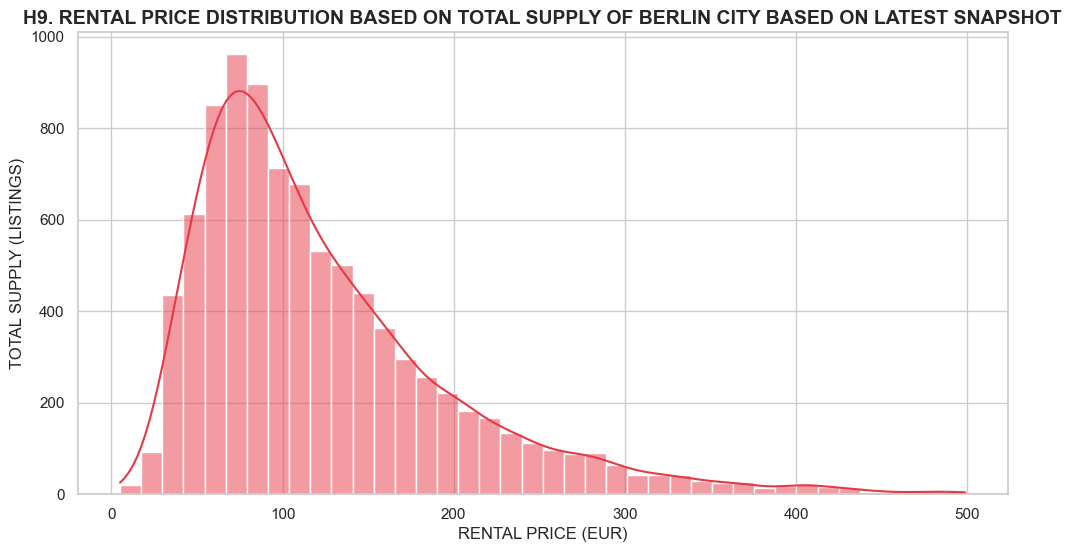

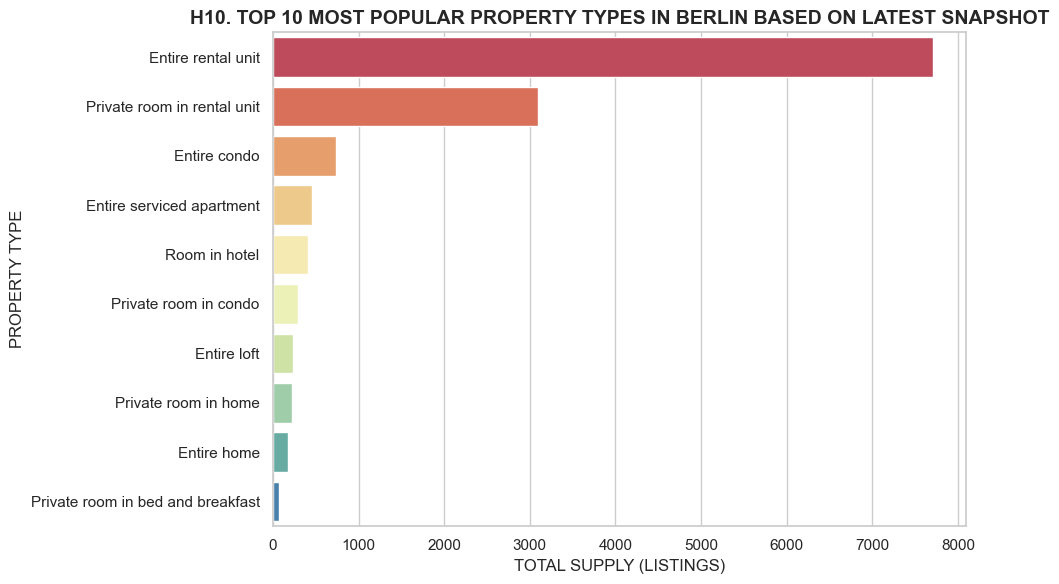

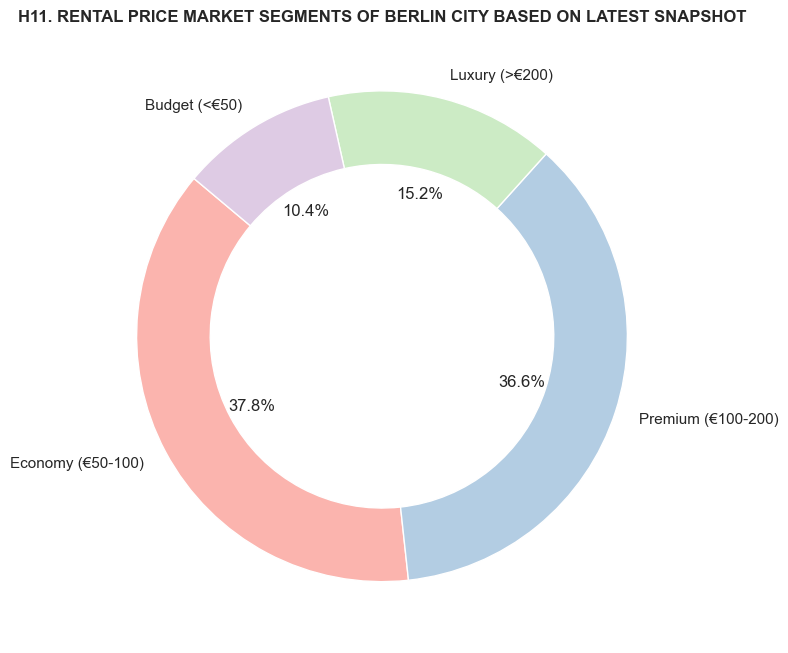

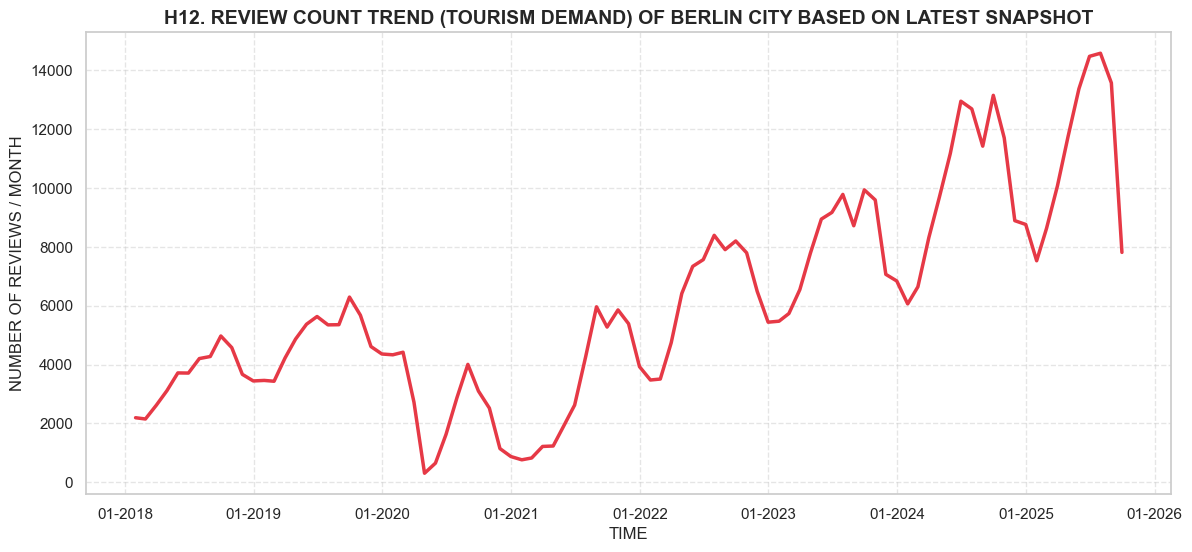

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as PathEffects
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# --- 1. SETUP ---
sns.set_theme(style="whitegrid")
BASE_DIR = '..'
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed', 'berlin')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
CITY_SUFFIX = 'berlin'

print("--- STARTING IN-DEPTH VISUALIZATIONS FOR BERLIN ---")

# --- 2. LOAD KPI DATA ---
try:
    kpi_supply = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_summary_general_{CITY_SUFFIX}.csv'))
    kpi_room = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_room_type_{CITY_SUFFIX}.csv'))
    kpi_season = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_seasonality_{CITY_SUFFIX}.csv'))
    # Load 2 new files
    kpi_neigh = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_neighbourhood_{CITY_SUFFIX}.csv'))
    kpi_review = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_reviews_trend_{CITY_SUFFIX}.csv'))
    
    # Sort by time
    kpi_supply['dt'] = pd.to_datetime(kpi_supply['snapshot_date'], errors='coerce')
    kpi_supply = kpi_supply.sort_values('dt')
    print("--- LOADING AGGREGATED DATA ---")
except FileNotFoundError as e:
    print(f" Missing KPI file: {e}")
    kpi_supply = pd.DataFrame(); kpi_room = pd.DataFrame(); kpi_season = pd.DataFrame()
    kpi_neigh = pd.DataFrame(); kpi_review = pd.DataFrame()


# --- 3. LOAD DETAILED DATA ---
from datetime import datetime

def parse_snapshot_name(name):
    try:
        return datetime.strptime(name.strip(), "%d %B, %Y")
    except:
        return None

df_detail = pd.DataFrame()
LATEST_SNAPSHOT = "Unknown"

if os.path.exists(PROCESSED_DIR):
    raw_snaps = [
        d for d in os.listdir(PROCESSED_DIR)
        if os.path.isdir(os.path.join(PROCESSED_DIR, d))
    ]

    snapshots = [s for s in raw_snaps if parse_snapshot_name(s) is not None]
    snapshots = sorted(snapshots, key=lambda x: parse_snapshot_name(x), reverse=True)

    for snap in snapshots:
        file_path = os.path.join(PROCESSED_DIR, snap, 'listings_processed.csv')
        if os.path.exists(file_path):
            try:
                temp = pd.read_csv(file_path, low_memory=False)
                if not temp.empty and 'price_numeric' in temp.columns:
                    df_detail = temp
                    LATEST_SNAPSHOT = snap
                    break
            except: continue


# --- 4. PLOTTING CHARTS ---

# === H1: Supply Trend ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    ax1 = sns.barplot(data=kpi_supply, x='snapshot_date', y='total_listings', color='#E63946', width=0.5)
    plt.title('H1. TOTAL SUPPLY (LISTINGS) TREND OF BERLIN CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax1.containers: ax1.bar_label(i, padding=3, fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_01_supply.pdf'), format='pdf', bbox_inches='tight')
    plt.show()

# === H2: Price Trend ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(kpi_supply['snapshot_date'], kpi_supply['median_price'], marker='o', linewidth=3, color='#E63946')
    plt.fill_between(kpi_supply['snapshot_date'], kpi_supply['median_price'], color='#E63946', alpha=0.1)
    plt.title('H2. MEDIAN RENTAL PRICE TREND OF BERLIN CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.ylabel('MEDIAN PRICE (EUR)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for x, y in zip(kpi_supply['snapshot_date'], kpi_supply['median_price']):
        plt.text(x, y + 2, f"€{y:.0f}", ha='center', fontsize=11, fontweight='bold')
    plt.ylim(bottom=0, top=kpi_supply['median_price'].max()*1.2)
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_02_price.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


# === H3: Multi-Host Rate (Professional Hosts) ===
if not kpi_supply.empty and 'multi_host_rate' in kpi_supply.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(kpi_supply['snapshot_date'], kpi_supply['multi_host_rate'], marker='s', linewidth=3, color='#E63946')
    plt.title(f'H3. PROFESSIONAL HOST RATE (MULTI-HOST RATE) OF {CITY_SUFFIX.upper()} CITY OVER TIME',fontsize = 14, fontweight='bold')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.ylabel('RATE (%)')
    plt.ylim(0, 100)
    for x, y in zip(kpi_supply['snapshot_date'], kpi_supply['multi_host_rate']):
        plt.text(x, y + 2, f"{y:.1f}%", ha='center', fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_03_multi_host.pdf'), bbox_inches='tight')
    plt.show()

# === H4: Availability ===
if not kpi_supply.empty and 'median_avail_90' in kpi_supply.columns:
    plt.figure(figsize=(10, 6))
    ax12 = sns.barplot(data=kpi_supply, x='snapshot_date', y='median_avail_90', color='#E63946', width=0.5)
    plt.title(f'H4. MEDIAN AVAILABILITY TREND (NEXT 90 DAYS) OF {CITY_SUFFIX.upper()} CITY OVER TIME',fontsize = 14, fontweight='bold')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.ylabel('AVAILABLE DAYS (NEXT 90 DAYS)')
    for i in ax12.containers: ax12.bar_label(i, padding=3, fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_04_availability.pdf'), format= 'pdf', bbox_inches='tight')
    plt.show()

# === H5: Occupancy ===
if not kpi_season.empty:
    df_h5 = kpi_season.copy()
    df_h5['date_dt'] = pd.to_datetime(df_h5['date'], errors='coerce')
    df_h5['snapshot_dt'] = pd.to_datetime(df_h5['snapshot_date'], errors='coerce')

    latest_snap_dt = df_h5['snapshot_dt'].max()
    df_final_h5 = df_h5[df_h5['snapshot_dt'] == latest_snap_dt].sort_values('date_dt')

    if not df_final_h5.empty:
        plt.figure(figsize=(14, 7))
        sns.lineplot(data=df_final_h5, x='date_dt', y='occupancy_rate', color='#E63946', linewidth=2)
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        plt.title('H5. OCCUPANCY RATE TREND OF BERLIN CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
        plt.xlabel('TIME')
        plt.ylabel('OCCUPANCY RATE')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(0, 1.05)
        plt.savefig(os.path.join(FIGURES_DIR, 'berlin_05_occupancy.pdf'), format='pdf', bbox_inches='tight')
        plt.show()


# === H6: Room Type Structure (Grouped Bar) ===
if not kpi_room.empty:
    plt.figure(figsize=(12, 6))
    kpi_room['dt'] = pd.to_datetime(kpi_room['snapshot_date'], errors='coerce')
    kpi_room = kpi_room.sort_values('dt')
    
    ax3 = sns.barplot(data=kpi_room, x='snapshot_date', y='percentage', hue='room_type', palette='Set2')
    plt.title('H6. ROOM TYPE STRUCTURE OF BERLIN CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('PROPORTION (%)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.legend(title='ROOM TYPE', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax3.containers: ax3.bar_label(i, fmt='%.1f%%', padding=3, fontsize=9)
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_06_room_type.pdf'), format='pdf', bbox_inches='tight')
    plt.show()




    
# === H7: Top 10 neighborhoods with the most listings ===
if not df_detail.empty:
    top_supply = df_detail['neighbourhood_cleansed'].value_counts().head(10).reset_index()
    top_supply.columns = ['neighbourhood_cleansed', 'count']

    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_supply, y='neighbourhood_cleansed', x='count', 
                hue='neighbourhood_cleansed', palette='Reds_r', legend=False)
    
    plt.title('H7. TOP 10 NEIGHBORHOODS WITH THE HIGHEST TOTAL SUPPLY IN BERLIN BASED ON LATEST SNAPSHOT', 
              fontsize=14, fontweight='bold')
    
    plt.xlabel('TOTAL SUPPLY (LISTINGS)')
    plt.ylabel('NEIGHBORHOODS')
    
    for i, v in enumerate(top_supply['count']):
        plt.text(v + 10, i, f"{v}", va='center', fontweight='bold')
        
    plt.tight_layout()
    
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_07_top10_supply.pdf'), bbox_inches='tight')
    
    plt.show()


# === H8: Top 10 most expensive neighborhoods ===
if not df_detail.empty:
    neigh_price = df_detail.groupby('neighbourhood_cleansed')['price_numeric'].median().sort_values(ascending=False).head(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(data=neigh_price, y='neighbourhood_cleansed', x='price_numeric', 
                hue='neighbourhood_cleansed', palette='Blues_r', legend=False)
    
    
    plt.title('H8. TOP 10 MOST EXPENSIVE NEIGHBORHOODS (MEDIAN PRICE) IN BERLIN BASED ON LATEST SNAPSHOT', 
              fontsize=14, fontweight='bold')
    
    for i, v in enumerate(neigh_price['price_numeric']):
        plt.text(v + 1, i, f"€{v:.0f}", va='center')
        
    plt.xlabel('MEDIAN PRICE (EUR)')
    plt.ylabel('NEIGHBORHOODS')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_08_top10_price.pdf'), bbox_inches='tight')
    
    plt.show()


# === H9: Price Histogram ===
if not df_detail.empty:
    plt.figure(figsize=(12, 6))
    sns.histplot(df_detail[df_detail['price_numeric'] < 500]['price_numeric'], kde=True, bins=40, color='#E63946')
    plt.title('H9. RENTAL PRICE DISTRIBUTION BASED ON TOTAL SUPPLY OF BERLIN CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('RENTAL PRICE (EUR)')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_09_price_distribution.pdf'), format='pdf', bbox_inches='tight')
    plt.show()






# === H10: Top 10 Property Types ===
if not df_detail.empty and 'property_type' in df_detail.columns:
    top_props = df_detail['property_type'].value_counts().head(10)
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(y=top_props.index, x=top_props.values, 
                hue=top_props.index, palette='Spectral', legend=False)
    
   
    plt.title('H10. TOP 10 MOST POPULAR PROPERTY TYPES IN BERLIN BASED ON LATEST SNAPSHOT', 
              fontsize=14, fontweight='bold')
    
    plt.xlabel('TOTAL SUPPLY (LISTINGS)')
    plt.ylabel('PROPERTY TYPE')
    
    plt.tight_layout() 
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_10_property_type.pdf'), bbox_inches='tight')
    
    plt.show()



# === H11: Price Segments (Donut Chart) ===
if not df_detail.empty:
    plt.figure(figsize=(8, 8))
    bins = [0, 50, 100, 200, 10000]
    labels = ['Budget (<€50)', 'Economy (€50-100)', 'Premium (€100-200)', 'Luxury (>€200)']
    df_detail['price_segment'] = pd.cut(df_detail['price_numeric'], bins=bins, labels=labels)
    seg_counts = df_detail['price_segment'].value_counts()
    
    plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette('Pastel1'), wedgeprops=dict(width=0.3))
    plt.title('H11. RENTAL PRICE MARKET SEGMENTS OF BERLIN CITY BASED ON LATEST SNAPSHOT', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_11_price_segments.pdf'))
    plt.show()


# === H12: REVIEW COUNT TREND (TOURISM DEMAND) ===
if not kpi_review.empty:
    plt.figure(figsize=(14, 6))
    
    # 1. Find the latest snapshot (Most accurate logic)
    kpi_review['snap_dt'] = pd.to_datetime(kpi_review['snapshot_date'], errors='coerce')
    latest_snap_date = kpi_review['snap_dt'].max()
    
    # 2. Filter review data for that snapshot only
    df_rev_final = kpi_review[kpi_review['snap_dt'] == latest_snap_date].copy()
    
    # 3. Process dates
    df_rev_final['date'] = pd.to_datetime(df_rev_final['date'])
    df_rev_final = df_rev_final.sort_values('date')
    
    # 4. Filter years (2018 and later)
    df_rev_final = df_rev_final[df_rev_final['date'].dt.year >= 2018]

    # 5. Plot
    sns.lineplot(data=df_rev_final, x='date', y='review_count', color='#E63946', linewidth=2.5)
    
    plt.title(f'H12. REVIEW COUNT TREND (TOURISM DEMAND) OF {CITY_SUFFIX.upper()} CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.ylabel('NUMBER OF REVIEWS / MONTH')
    plt.xlabel('TIME')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    plt.savefig(os.path.join(FIGURES_DIR, 'berlin_12_reviews_trend.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(" No Review Trend data available to draw H12.")